In [3]:
import pandas as pd
import xarray as xr
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
import seaborn as sns

colormap_std = sns.diverging_palette(230, 20, as_cmap=True)

def get_filtered_filenames(folder_path, filter="Snv_"):
    filenames = [
        f for f in os.listdir(folder_path)
        if f.endswith('.dat') and 'spectrum' in f and filter in f and os.path.isfile(os.path.join(folder_path, f))
    ]
    return filenames

def read_in_data(file_path):
    with open(file_path, 'r') as file:
        # read in metadata
        metadata = {}
        data_start_line = None
        for i, line in enumerate(file):
            if line.startswith("#"):
                # Extract key-value pairs from metadata
                if "=" in line:
                    key, value = line[2:].strip().split("=", 1)
                    metadata[key.strip()] = value.strip()
            else:
                data_start_line = i
                break
            
        data = pd.read_csv(file_path, sep='\t', skiprows=data_start_line, header=None)
        
        xrData = xr.Dataset(
                data_vars=dict(
                    intensity=xr.Variable('wavelength', data[1] , dict(units=r'au', long_name='Intensity')),             
                ),
                coords=dict(
                    wavelength=xr.Variable('wavelength', data[0]*1e-9, attrs=dict(units=r'nm', long_name='Wavelength')),
                    
                )
            )
    return xrData

# Lorentzian function
def lorentzian(x, x0, gamma, A):
    return A * gamma**2 / ((x - x0)**2 + gamma**2)

# Two Lorentzians
def double_lorentzian(x, x01, gamma1, A1, x02, gamma2, A2, offset):
    return (lorentzian(x, x01, gamma1, A1) +
            lorentzian(x, x02, gamma2, A2)) + offset

# Gaussian function
def gaussian(x, x0, sigma, A):
    return A * np.exp(-(x - x0)**2 / (2 * sigma**2))

# Two Gaussians
def double_gaussian(x, x01, sigma1, A1, x02, sigma2, A2):
    return (gaussian(x, x01, sigma1, A1) +
            gaussian(x, x02, sigma2, A2))

def fit_data_with_peak_finding(x_data, y_data, model='lorentzian'):
    # Find peaks
    try:
        peaks, _ = find_peaks(y_data, height=np.max(y_data) * -0.5)  # Detect peaks above 10% of max height
        peak_indices = peaks[np.argsort(y_data[peaks])][-2:]  # Get indices of the two tallest peaks
        peak_indices = np.sort(peak_indices)  # Ensure order consistency
        
        x01_guess, x02_guess = x_data[peak_indices]
        y01_guess, y02_guess = y_data[peak_indices]
        
        if model == 'lorentzian':
            p0 = [x01_guess, 1, y01_guess,  # Initial guess for first Lorentzian
                x02_guess, 1, y02_guess, 0]  # Initial guess for second Lorentzian
            # bounds =  [[-np.inf, -0.5, -np.inf, -np.inf, -0.5, -np.inf, -np.inf], [np.inf, 0.5, np.inf, np.inf, 0.5, np.inf, np.inf]]
            popt, pcov = curve_fit(double_lorentzian, x_data, y_data, p0=p0) #, bounds=bounds)
        elif model == 'gaussian':
            p0 = [x01_guess, 0.1, y01_guess,  # Initial guess for first Gaussian
                x02_guess, 0.1, y02_guess]  # Initial guess for second Gaussian
            popt, pcov = curve_fit(double_gaussian, x_data, y_data, p0=p0)
        else:
            raise ValueError("Model must be 'lorentzian' or 'gaussian'.")
        
        return popt, pcov
    except BaseException as e:
        return None, None
    
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from lmfit import Model

# Define the double Lorentzian function
def double_lorentzian_model(x, x01, gamma1, A1, x02, gamma2, A2, offset):
    """
    Double Lorentzian model:
      L(x) = A1 * gamma1^2 / ((x - x01)^2 + gamma1^2)
           + A2 * gamma2^2 / ((x - x02)^2 + gamma2^2)
           + offset
    """
    term1 = A1 * gamma1**2 / ((x - x01)**2 + gamma1**2)
    term2 = A2 * gamma2**2 / ((x - x02)**2 + gamma2**2)
    return term1 + term2 + offset

def fit_data_with_lmfit(x_data, y_data):
    """
    Fits data to a double Lorentzian model using lmfit.
    
    Parameters:
        x_data (np.array): The independent variable.
        y_data (np.array): The data to be fitted.
        
    Returns:
        result (lmfit.model.ModelResult): The fit result with best-fit parameters.
    """
    # --- 1. Find Peaks for Initial Guesses ---
    # Here, we use find_peaks with a minimum height and prominence.
    # Adjust these parameters based on your data.
    height_threshold = 0.1 * np.max(y_data)
    prominence_threshold = 0.1 * np.max(y_data)
    peaks, properties = find_peaks(y_data, height=height_threshold, prominence=prominence_threshold)

    if len(peaks) < 2:
        print("Warning: Fewer than 2 peaks found; using default guesses.")
        # Use the global maximum and an arbitrary shift for the second peak
        x01_guess = x_data[np.argmax(y_data)]
        A1_guess = np.max(y_data)
        # Offset the second peak guess by a small fraction of the x-range
        x02_guess = x01_guess + (x_data[-1] - x_data[0]) * 0.05
        A2_guess = A1_guess * 0.5
    else:
        # Select the two tallest peaks
        sorted_peaks = peaks[np.argsort(properties["peak_heights"])][-2:]
        sorted_peaks = np.sort(sorted_peaks)  # Ensure increasing order in x
        x01_guess = x_data[sorted_peaks[0]]
        x02_guess = x_data[sorted_peaks[1]]
        A1_guess = y_data[sorted_peaks[0]]
        A2_guess = y_data[sorted_peaks[1]]

    # A simple guess for the widths: 1% of the x-range (adjust as needed)
    gamma_guess = (x_data[-1] - x_data[0]) * 0.01

    # Guess the offset as the minimum of the data (or use another baseline estimate)
    offset_guess = np.min(y_data)

    # --- 2. Set Up the Model and Parameters ---
    model = Model(double_lorentzian_model)
    params = model.make_params(
        x01=x01_guess, gamma1=gamma_guess, A1=A1_guess,
        x02=x02_guess, gamma2=gamma_guess, A2=A2_guess,
        offset=offset_guess
    )

    # Constrain gamma to be strictly positive
    params['gamma1'].set(min=0)
    params['gamma2'].set(min=0)

    # (Optional) You can also constrain the peak positions if you know an expected range:
    # params['x01'].set(min=x_data[0], max=x_data[-1])
    # params['x02'].set(min=x_data[0], max=x_data[-1])

    # --- 3. Perform the Fit ---
    result = model.fit(y_data, params, x=x_data)
    return result

def get_name(filename):
    match = re.search(r"spectrum_(.*?)\.dat", filename)
    if match:
        return match.group(1)
    return "error"

def wavelength_to_freq_diff(wavelength1, wavelength2):
    # Speed of light in m/s
    c = 3e8
    # Convert wavelengths from nm to meters
    lambda1_m = wavelength1 * 1e-9
    lambda2_m = wavelength2 * 1e-9
    # Calculate frequencies in Hz
    freq1 = c / lambda1_m
    freq2 = c / lambda2_m
    # Frequency difference in Hz
    freq_diff_hz = abs(freq1 - freq2)
    # Convert to GHz
    freq_diff_ghz = freq_diff_hz / 1e9
    
    return freq_diff_ghz

def read_in_pois(filepath):
    """
    Reads a data file with metadata and converts it into an xarray.DataArray.
    Assumes the file contains metadata as commented lines (starting with '#')
    and numerical data in a tabular format.

    Parameters:
        filepath (str): Path to the file.

    Returns:
        xarray.DataArray: 2D array with x and y axes in micrometers.
    """
    # Step 1: Determine where the data starts
    with open(filepath, 'r') as file:
        metadata = {}
        data_start_line = None
        for i, line in enumerate(file):
            if line.startswith("#"):
                # Extract key-value pairs from metadata
                if "=" in line:
                    key, value = line[2:].strip().split("=", 1)
                    metadata[key.strip()] = value.strip()
            else:
                data_start_line = i
                break
    # Step 2: Read the numerical data into a Pandas DataFrame
    data = pd.read_csv(filepath, skiprows=data_start_line, delimiter='\t', header=None, names=['x', 'y', 'z'])
    data['x'] = data['x'] * 1e6
    data['y'] = data['y'] * 1e6
    data['z'] = data['z'] * 1e6
    # Step 3: Define axes in micrometers

    return data

def read_in_confocal(filepath):
    """
    Reads a data file with metadata and converts it into an xarray.DataArray.
    Assumes the file contains metadata as commented lines (starting with '#')
    and numerical data in a tabular format.

    Parameters:
        filepath (str): Path to the file.

    Returns:
        xarray.DataArray: 2D array with x and y axes in micrometers.
    """
    # Step 1: Determine where the data starts
    with open(filepath, 'r') as file:
        metadata = {}
        data_start_line = None
        for i, line in enumerate(file):
            if line.startswith("#"):
                # Extract key-value pairs from metadata
                if "=" in line:
                    key, value = line[2:].strip().split("=", 1)
                    metadata[key.strip()] = value.strip()
            else:
                data_start_line = i
                break
    # Step 2: Read the numerical data into a Pandas DataFrame
    data = pd.read_csv(filepath, skiprows=data_start_line, delimiter='\t', header=None)

    # Step 3: Define axes in micrometers
    x_range_m = eval(metadata['x scan range'])
    y_range_m = eval(metadata['y scan range'])
    x_res = int(metadata['x axis resolution'])
    y_res = int(metadata['y axis resolution'])

    x_axis = np.linspace(*x_range_m, x_res) * 1e6
    y_axis = np.linspace(*y_range_m, y_res) * 1e6   


    xrData = xr.Dataset(
        data_vars=dict(
            intensity=xr.Variable(['x', 'y'], data.values*1e-3 , dict(units=r'kCts', long_name='Intensity')),             
        ),
        coords=dict(
            x=xr.Variable('x', x_axis, attrs=dict(units=r'um', long_name='x')),
            y=xr.Variable('y', y_axis, attrs=dict(units=r'um', long_name='y')),
            
        )
    )

    return xrData, metadata

cmap = plt.get_cmap('binary')
num_colors = 1000

# Generate the list of colors
colors = [cmap(i / num_colors) for i in range(num_colors)]
def calculate_percent(value, min_value, max_value):
    percent = ((value - min_value) / (max_value - min_value)) * 100
    return percent



In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from cycler import cycler

# --- Globale Einstellungen ---

# Schriftart auf Futura setzen (stelle sicher, dass Futura auf deinem System verfügbar ist)
mpl.rcParams['font.family'] = 'Arial'#'Futura'

# Definiere einen modernen Farbsatz (du kannst die Hex-Codes nach Belieben anpassen)
modern_colors = ['#2E86AB', '#F6C85F', '#6F4E7C', '#CA472F', '#1B9E77', '#D72638']
mpl.rcParams['axes.prop_cycle'] = cycler(color=modern_colors)

# Optionale weitere Einstellungen für ein modernes Aussehen
mpl.rcParams['lines.linewidth'] = 2         # Liniendicke
mpl.rcParams['lines.markersize'] = 6          # Markergröße
#mpl.rcParams['grid.linestyle'] = '--'         # Gitterlinien als gestrichelte Linie
#mpl.rcParams['grid.alpha'] = 0.7              # Transparenz des Gitters
mpl.rcParams['axes.grid'] = False              # Gitter anzeigen
mpl.rcParams['figure.figsize'] = (10, 6)        # Standardgröße der Abbildungen
mpl.rcParams['axes.titlesize'] = 30           # Größe des Achsentitels
mpl.rcParams['axes.labelsize'] = 25           # Größe der Achsenbeschriftungen
mpl.rcParams['xtick.labelsize'] = 20          # Größe der x-Achsen-Tick-Beschriftungen
mpl.rcParams['ytick.labelsize'] = 20          # Größe der y-Achsen-Tick-Beschriftungen


# Read in Calibration

In [5]:
# Readin claibration
xrCalibration = xr.open_dataset("calibration_20_12_2024.h5")
calibration_popt = xrCalibration.attrs['popt']

# Readin Spectrometer data and fit double lorenzian

In [19]:
#### in waveguides ####
# 100keV
#folder_path = '/Users/colinsauerzapf/bwSyncShare/01_Uni Stuttgart/PhD/Data/2024-12-19/spectrometerlogic'
#filter_keyword = "_SnV"
# 60keV
#folder_path = '/Users/colinsauerzapf/bwSyncShare/01_Uni Stuttgart/PhD/60_Data/2024_12_spectrometer_waveguide/2024-12-20/spectrometerlogic'
#filter_keyword = "12_60keV"
#### bulk ####
#folder_path = '/Users/colinsauerzapf/bwSyncShare/01_Uni Stuttgart/PhD/60_Data/2024_12_spectrometer_waveguide/2024-12-20/spectrometerlogic'
#filter_keyword = "bulk"

#### fiber collection ###
folder_path = r'\\pi3-file\transfer\QINU\05_Data\2025-02-19_fiber-coupled-spectra' # '/Users/colinsauerzapf/bwSyncShare/01_Uni Stuttgart/PhD/60_Data/2025-02-19_fiber-coupled-spectra'
filter_keyword = "_long"

filepaths: list[str] = get_filtered_filenames(folder_path, filter=filter_keyword)
data_dict = {}
not_fitted: list[str] = []
# Read in all relevant spectrometer data
for filepath in filepaths:
    # Read in spectrometer data
    xrData = read_in_data(rf"{folder_path}\{filepath}")
    # Ajust wavelength axis using calibration
    xrData['wavelength'] = xrData.wavelength * calibration_popt[0] + calibration_popt[1]
    xrData = xrData.sel(wavelength=slice(615, 625))

    # Fit spectrometer data with double lorenzian
    try:
        fit_res = fit_data_with_lmfit(np.array(xrData.wavelength), np.array(xrData.intensity))
        xrData.attrs["name"] = get_name(filepath)
        param_dict = fit_res.params.valuesdict()
        xrData.attrs["strain_GHz"] = wavelength_to_freq_diff(param_dict['x01'], param_dict['x02'])
        data_dict[get_name(filepath)] = {'data': xrData, 'fit_res': fit_res}
    except BaseException:
        not_fitted.append(get_name(filepath))

print(f"Not fitted: {not_fitted}")

Not fitted: []


# Histogram of strain distribution

SnV_2_fiber-collection_long_integration, Strain: 844 GHz
SnV_3_fiber-collection_long_integration, Strain: 987 GHz
SnV_4_fiber-collection_long_integration, Strain: 968 GHz


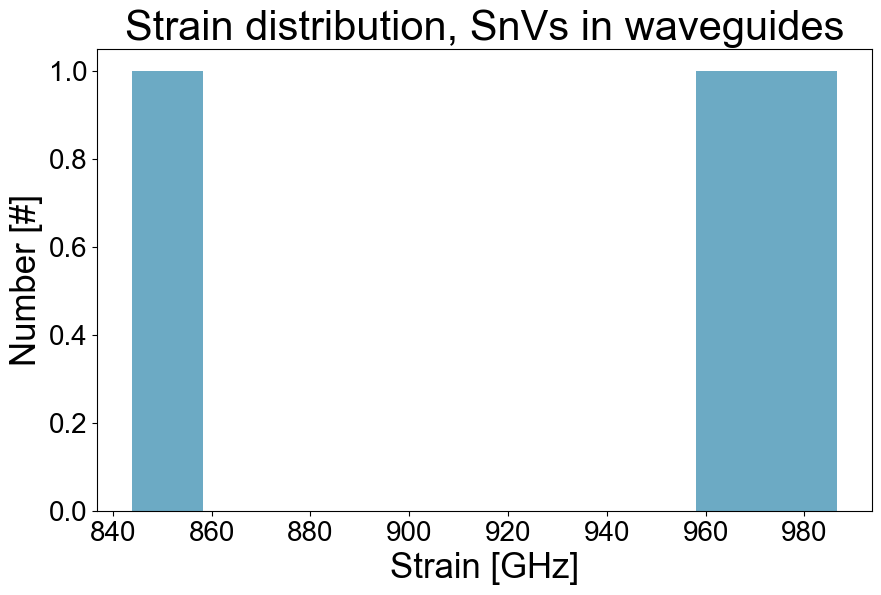

In [31]:
manual_exclude = ['end-of-waveguide_fiber-collection_long_integration', 'SnV_5_fiber-collection_long_integration'] # ['spectum_SnV_1', 'spectum_SnV_2', 'spectum_SnV_3', 'spectum_SnV_4', 'SnV_5_3', 'SnV_6_3', 'SnV_8_3', 'SnV_10_3', 'SnV_14_3', 'SnV_23_3', 'SnV_38_3', 'SnV_40_3', 'SnV_41_3', 'SnV_42_3', 'SnV_44_3', 'SnV_45_3', 'SnV_47_3', 'SnV_12_3']

strains: list[float] = []
filtered_spectra_names: list[str] = []
for data in data_dict.values():
    xrData = data['data']
    if 700 <= xrData.attrs['strain_GHz'] <= 1500 and xrData.attrs['name'] not in manual_exclude:
        print(f"{xrData.attrs['name']}, Strain: {xrData.attrs['strain_GHz']:.0f} GHz")
        strains.append(xrData.attrs['strain_GHz'])
# Filter out unrealistic data by range (maybe not the best method and prone to error)
# Plot histogram of strain
plt.hist(strains, bins=10, edgecolor='None', alpha=0.7)

# Add labels and title
plt.xlabel('Strain [GHz]')
plt.ylabel('Number [#]')
plt.title(f'Strain distribution, SnVs in waveguides')

# Show the plot
plt.show()


In [ ]:
xrData = read_in_data(r"C:\Users\yy3\qudi\Data\2025\02\2025-02-21\spectrometerlogic\20250221-1358-24_spectrum_test_test_test.dat")


# Plot spectrum with fit

SnV_3_fiber-collection_long_integration, Strain: 987 GHz


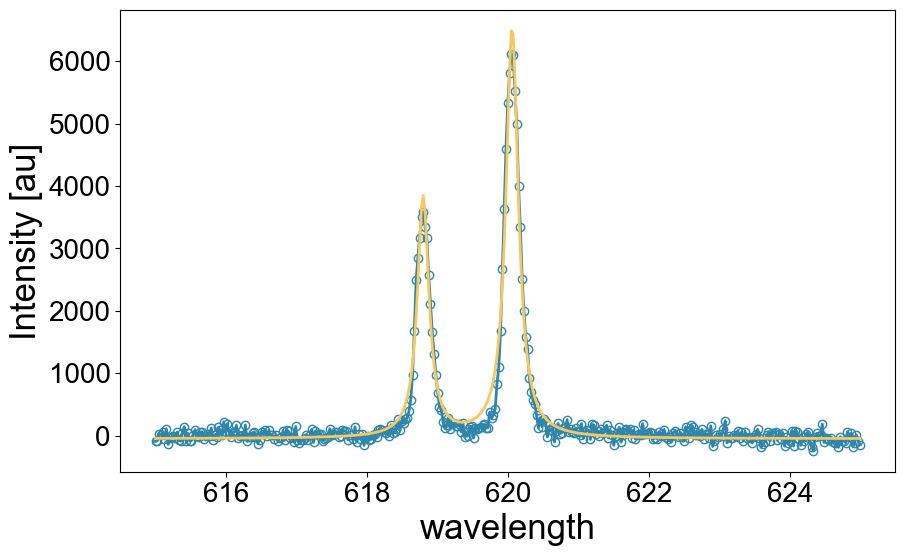

In [30]:
name = "SnV_3_fiber-collection_long_integration"
# exclude = ['SnV_5_3', 'SnV_6_3', 'SnV_8_3', 'SnV_10_3', 'SnV_14_3', 'SnV_23_3', 'SnV_38_3', 'SnV_40_3', 'SnV_41_3', 'SnV_42_3', 'SnV_44_3', 'SnV_45_3', 'SnV_47_3']

data = data_dict[name]
xrData = data['data']
print(f"{xrData.attrs['name']}, Strain: {xrData.attrs['strain_GHz']:.0f} GHz")
xrData.intensity.plot(label="Data", marker='o', fillstyle='none', linestyle='-')
fit_data = double_lorentzian_model(xrData.wavelength, **data['fit_res'].params.valuesdict())
plt.plot(xrData.wavelength, fit_data, label='Fitted Data')
plt.show()

In [187]:
data['fit_res'].params.valuesdict()

{'x01': 618.7485058020814,
 'gamma1': 0.09208064105119518,
 'A1': 5359.8826892773295,
 'x02': 619.8273469183,
 'gamma2': 0.0994786424385583,
 'A2': 17296.84693093535,
 'offset': -40.42942508905344}

In [ ]:
0.09208064105119518

SnV_31_3, Strain: 850 GHz
SnV_28_3, Strain: 841 GHz
SnV_27_3, Strain: 943 GHz
SnV_24_3, Strain: 838 GHz
SnV_2_3, Strain: 873 GHz
SnV_3_3, Strain: 842 GHz
SnV_15_3, Strain: 954 GHz
SnV_21_3, Strain: 836 GHz
SnV_35_3, Strain: 836 GHz
SnV_19_3, Strain: 842 GHz
SnV_11_3, Strain: 842 GHz
SnV_30_3, Strain: 846 GHz
SnV_48_3, Strain: 978 GHz
SnV_36_3, Strain: 836 GHz
SnV_39_3, Strain: 1006 GHz
SnV_1_3, Strain: 837 GHz
SnV_33_3, Strain: 933 GHz
SnV_20_3, Strain: 854 GHz
SnV_18_3, Strain: 851 GHz
SnV_9_3, Strain: 884 GHz
SnV_3_2, Strain: 1032 GHz
SnV_16_3, Strain: 849 GHz
SnV_22_3, Strain: 937 GHz
SnV_7_3, Strain: 903 GHz
SnV_46_3, Strain: 858 GHz
SnV_34_3, Strain: 843 GHz
SnV_17_3, Strain: 1079 GHz
SnV_32_3, Strain: 842 GHz
SnV_29_3, Strain: 838 GHz
SnV_37_3, Strain: 845 GHz
SnV_25_3, Strain: 843 GHz
SnV_4_3, Strain: 838 GHz
SnV_43_3, Strain: 889 GHz
SnV_1_2, Strain: 1076 GHz
SnV_49_3, Strain: 840 GHz
SnV_13_3, Strain: 904 GHz
SnV_26_3, Strain: 856 GHz
Fitted Gaussian parameters: μ = 886.36 GHz

/opt/anaconda3/envs/squdi-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 956 (\N{GREEK SMALL LETTER MU}) missing from font(s) Futura.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/squdi-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 963 (\N{GREEK SMALL LETTER SIGMA}) missing from font(s) Futura.
  fig.canvas.print_figure(bytes_io, **kw)


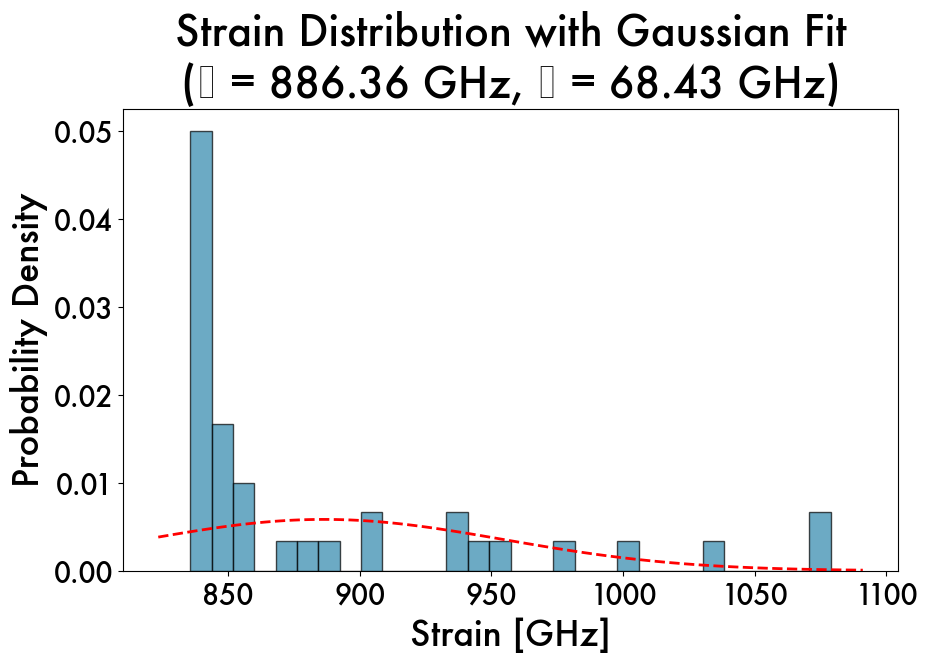

In [149]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- Your existing data processing ---
# manual_exclude = []# ['SnV_25_wg_12_60keV']

strains: list[float] = []
filtered_spectra_names: list[str] = []
for data in data_dict.values():
    xrData = data['data']
    if 750 <= xrData.attrs['strain_GHz'] <= 1500 and xrData.attrs['name'] not in manual_exclude:
        print(f"{xrData.attrs['name']}, Strain: {xrData.attrs['strain_GHz']:.0f} GHz")
        strains.append(xrData.attrs['strain_GHz'])
    else:
        not_fitted.append(xrData.attrs['name'])

# --- Fit Gaussian distribution to the data ---
# Estimate the mean (mu) and standard deviation (std) of the strains
mu, std = norm.fit(strains)
print(f"Fitted Gaussian parameters: μ = {mu:.2f} GHz, σ = {std:.2f} GHz")

# --- Plot histogram and the fitted Gaussian curve ---
# Use density=True so the histogram is normalized to form a probability density
plt.hist(strains, bins=30, density=True, edgecolor='black', alpha=0.7)

# Generate values on the x-axis for plotting the fitted Gaussian PDF
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# Plot the Gaussian fit over the histogram
plt.plot(x, p, 'r--', linewidth=2)

# Add labels and title
plt.xlabel('Strain [GHz]')
plt.ylabel('Probability Density')
plt.title(f'Strain Distribution with Gaussian Fit\n(μ = {mu:.2f} GHz, σ = {std:.2f} GHz)')

# Show the plot
plt.show()


In [ ]:
name = "SnV_28_wg_12_60keV"

xrData_all = data_dict[name]
print(f"{xrData_all.attrs['name']}, Strain: {xrData_all.attrs['strain_GHz']:.0f} GHz")
xrData = xrData_all.sel(wavelength=slice(615, 625))
xrData.intensity.plot(label="Data", marker='o', fillstyle='none', linestyle='-')
fit_data = double_lorentzian(xrData.wavelength, *xrData.attrs["popt"])
plt.plot(xrData.wavelength, fit_data, label='Fitted Data')
plt.show()
fit_data_with_lmfit

In [7]:
data_dict

{}

In [13]:
name = "SnV_28_wg_12_60keV"
xrData_all = data_dict[name]
result = fit_data_with_lmfit(np.array(xrData_all.wavelength), np.array(xrData_all.intensity))

In [15]:
for name, param in result.params.items():
    print(f"{name} = {param.value} ± {param.stderr}")

x01 = 619.3284125523262 ± 0.0004643237354007962
gamma1 = 0.05784248465263864 ± 0.000659441747503222
A1 = 8696.505903067553 ± 69.71880323747303
x02 = 620.4144874979055 ± 0.0008466330429944972
gamma2 = 0.063644347326824 ± 0.0012028277831581855
A2 = 4998.784420803882 ± 66.40841994003414
offset = 40.62932830042754 ± 2.588764709168682


In [19]:
result.params.valuesdict()['x01']

619.3284125523262

In [23]:
xrData.attrs["popt"]

array([ 6.19071913e+02, -5.15171487e-02,  9.56974804e+03,  6.20145864e+02,
        5.69060573e-02,  3.75908978e+03])

In [150]:
#### waveguide 100keV ###
filepath_confocal = '/Users/colinsauerzapf/bwSyncShare/01_Uni Stuttgart/PhD/20241219-1829-45_2D-scan_with_xy_axes_from_channel_APD3_large_scan.dat'
filepath_pois = '/Users/colinsauerzapf/bwSyncShare/01_Uni Stuttgart/PhD/20241219-1900-22_Sample237_Waveguides_100keV_13_poi_list.dat'
#### waveguide 60keV ####
#filepath_confocal = '/Users/colinsauerzapf/bwSyncShare/01_Uni Stuttgart/PhD/60_Data/2024_12_spectrometer_waveguide/2024-12-20/scanning_data_logic/20241220-1213-08_2D-scan_with_xy_axes_from_channel_APD3_waveguides_60keV_pos_12.dat'
#filepath_pois = '/Users/colinsauerzapf/bwSyncShare/01_Uni Stuttgart/PhD/60_Data/2024_12_spectrometer_waveguide/2024-12-20/poi_manager_logic/20241220-1213-31_Sample237_waveguides_60keV_pos_12_poi_list.dat'

xrConfocal, metadata_confocal = read_in_confocal(filepath_confocal)
data_pois = read_in_pois(filepath_pois)

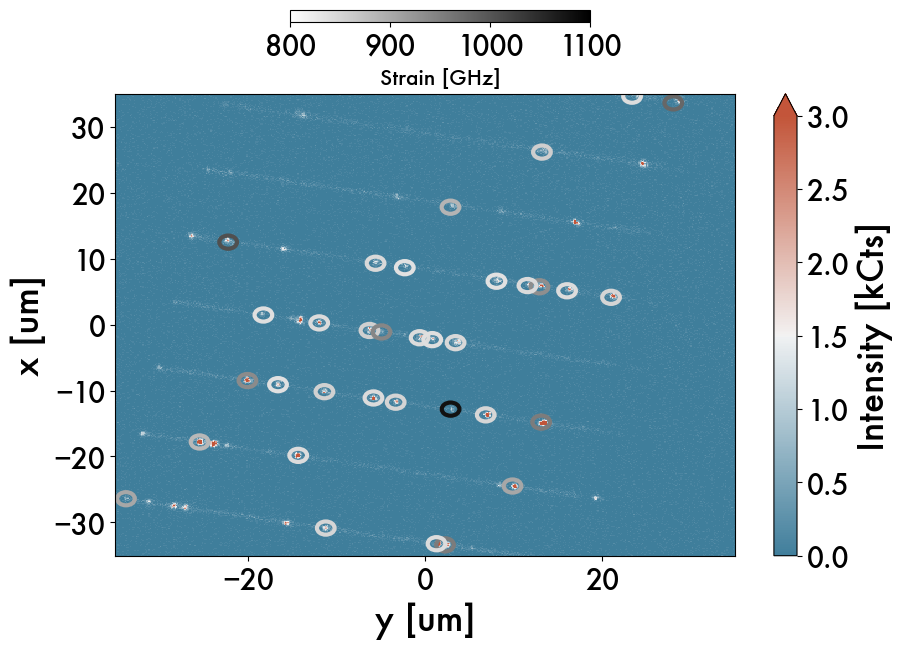

In [167]:
from matplotlib.patches import Circle
import matplotlib.pyplot as plt
import matplotlib.colorbar as cbar
import matplotlib.colors as mcolors
import numpy as np

# Plot confocal colormap
fig, ax = plt.subplots()
xrConfocal.intensity.plot.imshow(vmax=3, ax=ax, cmap=colormap_std)

maxSplitt = 1100
minSplitt = 800

def name(label):
    for name in data_dict.keys():
        if label in name:
            return name
    return ""

# Add circles with "strain color" and labels
for x, y, label in zip(list(data_pois['x']), list(data_pois['y']), list(data_pois.index)):
    # Add circle
    _name = name(label)
    if not _name in not_fitted and _name != "":
        xrData_spectrum = data_dict[_name]['data']

        color = colors[int(calculate_percent(xrData_spectrum.attrs['strain_GHz'], minSplitt, maxSplitt)*1e1)]
        circle = Circle((y, x), 1, color=color, fill=False, linewidth=3)
        ax.add_patch(circle)
            # Add label next to the circle
            # ax.text(y+1.5, x+1.5, label, color='white', fontsize=6, va='center')



# Add the strain colorbar
cbar_ax = fig.add_axes([0.3, 1, 0.3, 0.02])  # Position: [left, bottom, width, height]
cb = cbar.ColorbarBase(
    cbar_ax,
    cmap=mcolors.ListedColormap(colors),
    norm=mcolors.Normalize(vmin=minSplitt, vmax=maxSplitt),
    orientation='horizontal',  # Horizontal colorbar
)
cb.set_label('Strain [GHz]', fontsize=15)

plt.show()

In [3]:
years = 20
base = 15 # Mio
for i in range(years):
    base*= 1.03

print(base) 

27.09166852004122
